In [40]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
import gc

from sklearn.metrics import mean_squared_error


In [41]:
data_path = '/Users/jisuhyeon/Downloads'

df= pd.read_csv(f'{data_path}/df_features.csv', parse_dates=['timestamp'])

print(df.shape)
print(df.dtypes)
df.head()

(20199231, 55)
building_id                     int64
meter                           int64
timestamp              datetime64[ns]
meter_reading                 float64
site_id                         int64
primary_use                    object
square_feet                     int64
air_temperature               float64
cloud_coverage                float64
dew_temperature               float64
precip_depth_1_hr             float64
sea_level_pressure            float64
wind_direction                float64
wind_speed                    float64
time_diff                      object
building_age                  float64
has_floor_count                 int64
log_meter_reading             float64
hour                            int64
day                             int64
weekday                         int64
month                           int64
is_weekend                      int64
hour_sin                      float64
hour_cos                      float64
month_sin                     float

,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed,time_diff,building_age,has_floor_count,log_meter_reading,hour,day,weekday,month,is_weekend,hour_sin,hour_cos,month_sin,month_cos,weekday_sin,weekday_cos,lag_1,lag_2,lag_3,lag_24,lag_48,lag_72,lag_168,rolling_mean_6,rolling_mean_12,rolling_mean_24,rolling_mean_72,rolling_std_24,diff_1,diff_24,log_square_feet,primary_use_encoded,building_mean,building_std,meter_normalized,CDD,HDD,temp_x_dew,temp_diff,humidity_like,temp_x_hour,temp_x_primary_use
0,0,0,2016-01-01 00:00:00,0.0,0,Education,7432,25.0,6.000000,20.0,0.0,1019.7,0.0,0.0,0,8.0,0,0.0,0,1,4,1,0,0.000000,1.000000,0.5,0.866025,-0.433884,-0.900969,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.913685,0,2.985282,2.762474,-2.985282,6.700000,0.0,500.00,5.000000,0.769231,0.000000,0.0
1,0,0,2016-01-01 01:00:00,0.0,0,Education,7432,24.4,5.961538,21.1,-1.0,1020.2,70.0,1.5,0 days 00:00:00,8.0,0,0.0,1,1,4,1,0,0.258819,0.965926,0.5,0.866025,-0.433884,-0.900969,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.913685,0,2.985282,2.762474,-2.985282,6.100000,0.0,514.84,3.299999,0.830709,24.400000,0.0
2,0,0,2016-01-01 02:00:00,0.0,0,Education,7432,22.8,2.000000,21.1,0.0,1020.2,0.0,0.0,0 days 00:00:00,8.0,0,0.0,2,1,4,1,0,0.500000,0.866025,0.5,0.866025,-0.433884,-0.900969,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,8.913685,0,2.985282,2.762474,-2.985282,4.499999,0.0,481.08,1.699999,0.886555,45.600000,0.0
3,0,0,2016-01-01 03:00:00,0.0,0,Education,7432,21.1,2.000000,20.6,0.0,1020.1,0.0,0.0,0 days 00:00:00,8.0,0,0.0,3,1,4,1,0,0.707107,0.707107,0.5,0.866025,-0.433884,-0.900969,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,8.913685,0,2.985282,2.762474,-2.985282,2.800000,0.0,434.66,0.500000,0.932127,63.300003,0.0
4,0,0,2016-01-01 04:00:00,0.0,0,Education,7432,20.0,2.000000,20.0,-1.0,1020.0,250.0,2.6,0 days 00:00:00,8.0,0,0.0,4,1,4,1,0,0.866025,0.500000,0.5,0.866025,-0.433884,-0.900969,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,8.913685,0,2.985282,2.762474,-2.985282,1.700000,0.0,400.00,0.000000,0.952381,80.000000,0.0


In [42]:
feature_cols = [
    # 기본
    'building_id', 'site_id', 'meter',
    # 시간 (raw + cyclical 둘 다 넣어도 무방, LightGBM이 알아서 선택)
    'hour', 'weekday', 'month', 'is_weekend',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'weekday_sin', 'weekday_cos',
    # 건물
    'log_square_feet', 'primary_use_encoded', 'building_age', 'has_floor_count',
    'building_mean', 'building_std',
    # 날씨
    'air_temperature', 'dew_temperature', 'wind_speed', 'cloud_coverage',
    'precip_depth_1_hr', 'sea_level_pressure', 'CDD', 'HDD',
    'temp_x_dew', 'temp_x_primary_use',
    # 시계열
    'lag_1', 'lag_24', 'lag_168', 'rolling_mean_24', 'rolling_std_24',
]

target_col = 'log_meter_reading'

# 실제 df에 다 있는지 확인
missing_cols = [c for c in feature_cols if c not in df.columns]
print('빠진 컬럼:', missing_cols)  # 빈 리스트여야 정상


빠진 컬럼: []


## Baseline : Linear Regression / RandomForest

In [43]:
#Train / Valid 분리 (시간 기준)
train_mask = df['timestamp'] < '2016-11-01'
valid_mask = df['timestamp'] >= '2016-11-01'

X_train = df.loc[train_mask, feature_cols]
y_train = df.loc[train_mask, target_col]

X_valid = df.loc[valid_mask, feature_cols]
y_valid = df.loc[valid_mask, target_col]

split_date = "2016-11-01"

train_idx = df['timestamp'] < split_date
valid_idx = df['timestamp'] >= split_date

X_train = df.loc[train_idx, feature_cols]
y_train = df.loc[train_idx, target_col]

X_valid = df.loc[valid_idx, feature_cols]
y_valid = df.loc[valid_idx, target_col]

print(f'train: {X_train.shape}, valid: {X_valid.shape}')

train: (16786316, 34), valid: (3412915, 34)


In [44]:
# 샘플링 + 원 핫 인코딩
import time
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# 10% 샘플링 (RandomForest/LinearRegression 모두 이 샘플로 비교)
sample_frac = 0.1
train_sample_idx = X_train.sample(frac=sample_frac, random_state=42).index

X_train_sample = X_train.loc[train_sample_idx].copy()
y_train_sample = y_train.loc[train_sample_idx].copy()

print(f'샘플 train: {X_train_sample.shape}, valid: {X_valid.shape}')

# 저카디널리티만 원-핫 (site_id, meter, primary_use_encoded)
ohe_cols = ['site_id', 'meter', 'primary_use_encoded']

X_train_ohe = pd.get_dummies(X_train_sample, columns=ohe_cols, drop_first=True)
X_valid_ohe = pd.get_dummies(X_valid, columns=ohe_cols, drop_first=True)

# train/valid 컬럼 정합성 맞추기 (한쪽에만 있는 카테고리 대비)
X_train_ohe, X_valid_ohe = X_train_ohe.align(X_valid_ohe, join='left', axis=1, fill_value=0)

X_train_ohe = X_train_ohe.fillna(0)
X_valid_ohe = X_valid_ohe.fillna(0)

print(f'원-핫 후 컬럼 수: {X_train_ohe.shape[1]}')

샘플 train: (1678632, 34), valid: (3412915, 34)
원-핫 후 컬럼 수: 64


In [45]:
#  Linear Regression
lr = LinearRegression()

start = time.time()
lr.fit(X_train_ohe, y_train_sample)
lr_train_time = time.time() - start

pred_lr = lr.predict(X_valid_ohe)
rmsle_lr = np.sqrt(mean_squared_error(y_valid, pred_lr))

print(f'Linear Regression 학습 시간: {lr_train_time:.1f}초')
print(f'Linear Regression RMSLE: {rmsle_lr:.4f}')

Linear Regression 학습 시간: 8.8초
Linear Regression RMSLE: 0.4693


In [46]:
# RandomForest 
pd.set_option('display.max_columns', None)

params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.05,
    'num_leaves': 128,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1
}

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    n_jobs=-1,
    random_state=42
)

start = time.time()
rf.fit(X_train_ohe, y_train_sample)
rf_train_time = time.time() - start

pred_rf = rf.predict(X_valid_ohe)
rmsle_rf = np.sqrt(mean_squared_error(y_valid, pred_rf))

print(f'RandomForest 학습 시간: {rf_train_time:.1f}초')
print(f'RandomForest RMSLE: {rmsle_rf:.4f}')

RandomForest 학습 시간: 798.1초
RandomForest RMSLE: 0.4422


In [47]:
# LightGBM도 같은 샘플로 재학습
train_data_sample = lgb.Dataset(X_train_sample, label=y_train_sample, categorical_feature=categorical_features)
valid_data_sample = lgb.Dataset(X_valid, label=y_valid, categorical_feature=categorical_features, reference=train_data_sample)

start = time.time()
model_sample = lgb.train(
    params,
    train_data_sample,
    num_boost_round=1000,
    valid_sets=[train_data_sample, valid_data_sample],
    valid_names=['train', 'valid'],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)
lgb_train_time = time.time() - start

pred_lgb_sample = model_sample.predict(X_valid, num_iteration=model_sample.best_iteration)
rmsle_lgb_sample = np.sqrt(mean_squared_error(y_valid, pred_lgb_sample))

print(f'LightGBM 학습 시간: {lgb_train_time:.1f}초')
print(f'LightGBM RMSLE: {rmsle_lgb_sample:.4f}')

Training until validation scores don't improve for 50 rounds
[100]	train's rmse: 0.429267	valid's rmse: 0.427275
[200]	train's rmse: 0.406759	valid's rmse: 0.42355
[300]	train's rmse: 0.393178	valid's rmse: 0.422973
[400]	train's rmse: 0.38185	valid's rmse: 0.422746
Early stopping, best iteration is:
[394]	train's rmse: 0.382441	valid's rmse: 0.422704
LightGBM 학습 시간: 34.1초
LightGBM RMSLE: 0.4227


               model     RMSLE  train_time_sec
0  Linear Regression  0.469284        8.807902
1       RandomForest  0.442190      798.129059
2           LightGBM  0.422704       34.092534


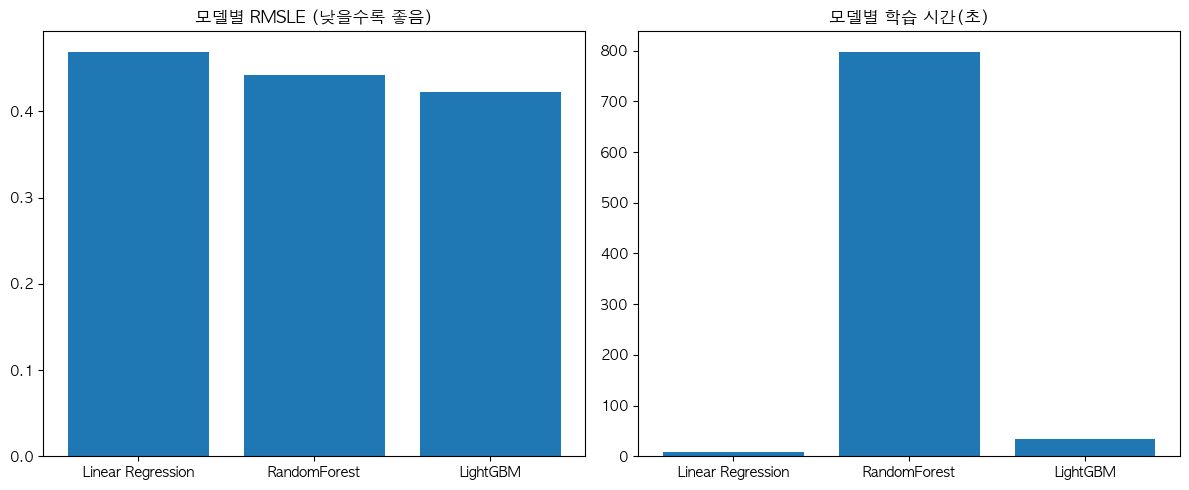

In [48]:
# 최종 비교표
comparison = pd.DataFrame({
    'model': ['Linear Regression', 'RandomForest', 'LightGBM'],
    'RMSLE': [rmsle_lr, rmsle_rf, rmsle_lgb_sample],
    'train_time_sec': [lr_train_time, rf_train_time, lgb_train_time]
})

print(comparison)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(12,5))
axes[0].bar(comparison['model'], comparison['RMSLE'])
axes[0].set_title('모델별 RMSLE (낮을수록 좋음)')
axes[1].bar(comparison['model'], comparison['train_time_sec'])
axes[1].set_title('모델별 학습 시간(초)')
plt.tight_layout()
plt.show()

## LightGBM modeling

In [49]:
# LightGBM 학습
import lightgbm as lgb
from sklearn.metrics import mean_squared_error
import numpy as np

categorical_features = ['building_id', 'site_id', 'meter', 'primary_use_encoded']

train_dataset = lgb.Dataset(
    X_train, 
    label=y_train,
    categorical_feature=categorical_features,
    free_raw_data=False
)

valid_dataset = lgb.Dataset(
    X_valid, 
    label=y_valid,
    categorical_feature=categorical_features,
    free_raw_data=False
)


params = {
    'objective': 'regression',
    'metric': 'rmse',

    'boosting_type': 'gbdt',

    'learning_rate': 0.03,   # 살짝 올림
    'num_leaves': 128,       # 증가
    'max_depth': -1,

    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,

    'lambda_l1': 1,
    'lambda_l2': 1,

    'seed': 42,
    'verbosity': -1
}

model = lgb.train(
    params,
    train_dataset,
    num_boost_round=2000,
    valid_sets=[train_dataset, valid_dataset],
    valid_names=['train', 'valid'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),
        lgb.log_evaluation(100)
    ]
)


Training until validation scores don't improve for 100 rounds
[100]	train's rmse: 0.463644	valid's rmse: 0.441104
[200]	train's rmse: 0.432315	valid's rmse: 0.42093
[300]	train's rmse: 0.422762	valid's rmse: 0.417686
[400]	train's rmse: 0.417801	valid's rmse: 0.416393
[500]	train's rmse: 0.414044	valid's rmse: 0.415526
[600]	train's rmse: 0.410455	valid's rmse: 0.414912
[700]	train's rmse: 0.407702	valid's rmse: 0.414387
[800]	train's rmse: 0.405273	valid's rmse: 0.414041
[900]	train's rmse: 0.402807	valid's rmse: 0.413686
[1000]	train's rmse: 0.400541	valid's rmse: 0.413399
[1100]	train's rmse: 0.398192	valid's rmse: 0.413274
[1200]	train's rmse: 0.396177	valid's rmse: 0.413102
[1300]	train's rmse: 0.394112	valid's rmse: 0.412925
[1400]	train's rmse: 0.392161	valid's rmse: 0.412788
[1500]	train's rmse: 0.390424	valid's rmse: 0.41263
[1600]	train's rmse: 0.388824	valid's rmse: 0.412582
[1700]	train's rmse: 0.387172	valid's rmse: 0.412398
[1800]	train's rmse: 0.385556	valid's rmse: 0.41

In [50]:
# RMSLE 확인 (baseline과 비교할 지표)
y_pred = model.predict(X_valid)

rmsle = np.sqrt(mean_squared_error(y_valid, y_pred))
print(f"Validation RMSLE: {rmsle:.5f}")

Validation RMSLE: 0.41213


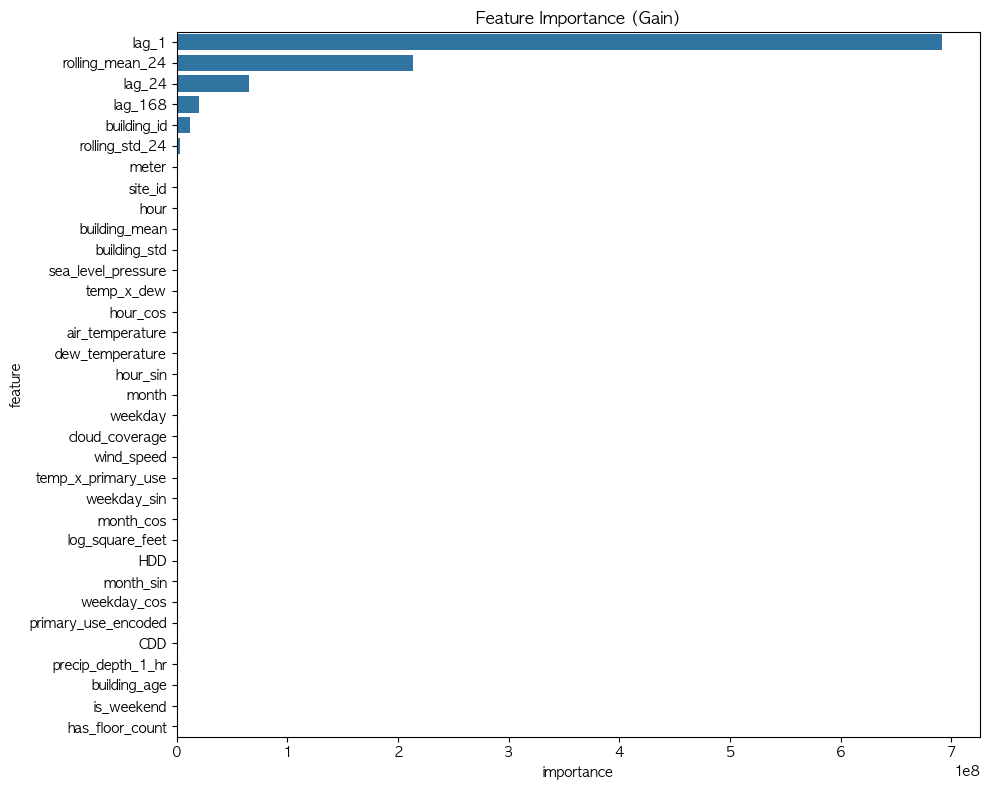

                feature    importance
29                lag_1  6.913462e+08
32      rolling_mean_24  2.133051e+08
30               lag_24  6.528099e+07
31              lag_168  1.985712e+07
0           building_id  1.177313e+07
33       rolling_std_24  2.860707e+06
2                 meter  1.544649e+06
1               site_id  1.433746e+06
3                  hour  1.042734e+06
17        building_mean  9.930519e+05
18         building_std  8.566612e+05
24   sea_level_pressure  7.854911e+05
27           temp_x_dew  7.849097e+05
8              hour_cos  7.829481e+05
19      air_temperature  7.741587e+05
20      dew_temperature  6.293307e+05
7              hour_sin  5.812642e+05
5                 month  3.775284e+05
4               weekday  3.603832e+05
22       cloud_coverage  3.531076e+05
21           wind_speed  3.369762e+05
28   temp_x_primary_use  3.338087e+05
11          weekday_sin  3.197286e+05
10            month_cos  1.928920e+05
13      log_square_feet  1.838914e+05
26          

In [51]:
#  Feature Importance 확인
importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(data=importance, x='importance', y='feature')
plt.title('Feature Importance (Gain)')
plt.tight_layout()
plt.show()

print(importance)

In [52]:
# lag/rolling 전부 제외한 feature set
feature_cols_no_lag = [c for c in feature_cols if c not in ['lag_1', 'lag_24', 'lag_168', 'rolling_mean_24', 'rolling_std_24']]

X_train_nolag = df.loc[train_mask, feature_cols_no_lag]
y_train_nolag = df.loc[train_mask, target_col]
X_valid_nolag = df.loc[valid_mask, feature_cols_no_lag]
y_valid_nolag = df.loc[valid_mask, target_col]

categorical_features_nolag = [c for c in categorical_features if c in feature_cols_no_lag]

train_data_nolag = lgb.Dataset(X_train_nolag, label=y_train_nolag, categorical_feature=categorical_features_nolag)
valid_data_nolag = lgb.Dataset(X_valid_nolag, label=y_valid_nolag, categorical_feature=categorical_features_nolag, reference=train_data_nolag)

model_nolag = lgb.train(
    params,
    train_data_nolag,
    num_boost_round=1000,
    valid_sets=[train_data_nolag, valid_data_nolag],
    valid_names=['train', 'valid'],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

pred_nolag = model_nolag.predict(X_valid_nolag, num_iteration=model_nolag.best_iteration)
rmsle_nolag = np.sqrt(mean_squared_error(y_valid_nolag, pred_nolag))

print(f'lag 포함 RMSLE: 0.4121')
print(f'lag 제외 RMSLE: {rmsle_nolag:.4f}')
print(f'성능 손실: {rmsle_nolag - 0.4121:.4f} ({(rmsle_nolag-0.4121)/0.4121*100:.1f}% 악화)')

Training until validation scores don't improve for 50 rounds
[100]	train's rmse: 0.944499	valid's rmse: 1.14398
[200]	train's rmse: 0.820048	valid's rmse: 1.06716
[300]	train's rmse: 0.76765	valid's rmse: 1.04408
[400]	train's rmse: 0.741073	valid's rmse: 1.03368
[500]	train's rmse: 0.72545	valid's rmse: 1.02968
[600]	train's rmse: 0.711527	valid's rmse: 1.02886
Early stopping, best iteration is:
[573]	train's rmse: 0.714887	valid's rmse: 1.02784
lag 포함 RMSLE: 0.4121
lag 제외 RMSLE: 1.0278
성능 손실: 0.6157 (149.4% 악화)


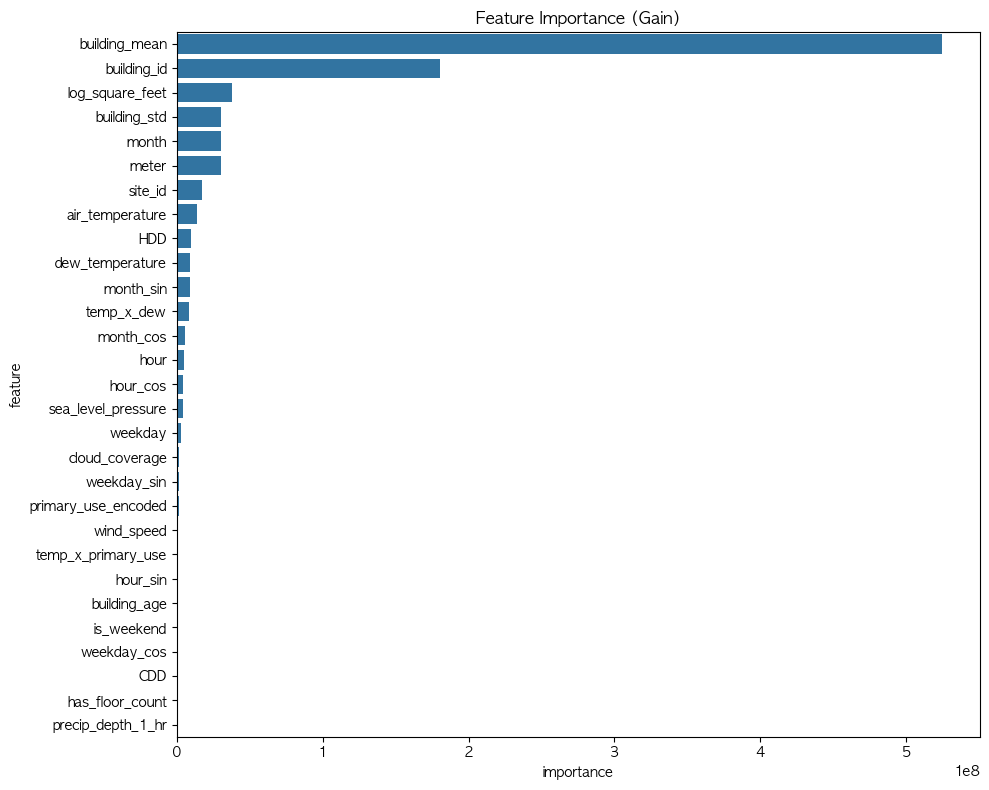

            feature    importance
17    building_mean  5.243090e+08
0       building_id  1.804291e+08
13  log_square_feet  3.780389e+07
18     building_std  3.063552e+07
5             month  3.033535e+07
2             meter  2.997770e+07
1           site_id  1.726546e+07
19  air_temperature  1.382137e+07
26              HDD  9.833679e+06
20  dew_temperature  9.323813e+06


In [53]:
# lag 없을 때 새로운 1순위는 뭐가 되는지
importance_nolag = pd.DataFrame({
    'feature': feature_cols_no_lag,
    'importance': model_nolag.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(data=importance_nolag, x='importance', y='feature')
plt.title('Feature Importance (Gain)')
plt.tight_layout()
plt.show()

print(importance_nolag.head(10))

## meter별 분석

In [54]:
meter_names = {0: 'electricity', 1: 'chilledwater', 2: 'steam', 3: 'hotwater'}

results = {}
models = {}
importances = {}

for meter_id, meter_name in meter_names.items():
    print(f'\n===== Meter {meter_id} ({meter_name}) 학습 시작 =====')
    
    # 해당 meter만 필터링
    meter_mask = df['meter'] == meter_id
    
    X_train_m = df.loc[train_mask & meter_mask, feature_cols]
    y_train_m = df.loc[train_mask & meter_mask, target_col]
    X_valid_m = df.loc[valid_mask & meter_mask, feature_cols]
    y_valid_m = df.loc[valid_mask & meter_mask, target_col]
    
    print(f'train: {X_train_m.shape}, valid: {X_valid_m.shape}')
    
    # meter는 이제 항상 같은 값이니 feature에서 제외
    features_m = [c for c in feature_cols if c != 'meter']
    categorical_features_m = [c for c in categorical_features if c != 'meter']
    
    train_data_m = lgb.Dataset(X_train_m[features_m], label=y_train_m, categorical_feature=categorical_features_m)
    valid_data_m = lgb.Dataset(X_valid_m[features_m], label=y_valid_m, categorical_feature=categorical_features_m, reference=train_data_m)
    
    model_m = lgb.train(
        params,
        train_data_m,
        num_boost_round=1000,
        valid_sets=[train_data_m, valid_data_m],
        valid_names=['train', 'valid'],
        callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
    )
    
    pred_valid_m = model_m.predict(X_valid_m[features_m], num_iteration=model_m.best_iteration)
    rmsle_m = np.sqrt(mean_squared_error(y_valid_m, pred_valid_m))
    
    results[meter_name] = rmsle_m
    models[meter_name] = model_m
    importances[meter_name] = pd.DataFrame({
        'feature': features_m,
        'importance': model_m.feature_importance(importance_type='gain')
    }).sort_values('importance', ascending=False)
    
    print(f'>>> {meter_name} RMSLE: {rmsle_m:.4f}')


===== Meter 0 (electricity) 학습 시작 =====
train: (10037678, 34), valid: (2023232, 34)
Training until validation scores don't improve for 50 rounds
[100]	train's rmse: 0.198524	valid's rmse: 0.178471
[200]	train's rmse: 0.165386	valid's rmse: 0.154526
[300]	train's rmse: 0.156502	valid's rmse: 0.15249
[400]	train's rmse: 0.150691	valid's rmse: 0.15184
[500]	train's rmse: 0.147792	valid's rmse: 0.151483
[600]	train's rmse: 0.145233	valid's rmse: 0.151215
[700]	train's rmse: 0.143327	valid's rmse: 0.15103
[800]	train's rmse: 0.141457	valid's rmse: 0.15083
[900]	train's rmse: 0.139891	valid's rmse: 0.15069
[1000]	train's rmse: 0.13848	valid's rmse: 0.150579
Did not meet early stopping. Best iteration is:
[969]	train's rmse: 0.138878	valid's rmse: 0.150546
>>> electricity RMSLE: 0.1505

===== Meter 1 (chilledwater) 학습 시작 =====
train: (3458335, 34), valid: (716020, 34)
Training until validation scores don't improve for 50 rounds
[100]	train's rmse: 0.492034	valid's rmse: 0.503534
[200]	train'

In [55]:
print('\n===== meter별 RMSLE 비교 =====')
for name, score in results.items():
    print(f'{name}: {score:.4f}')

# 통합 모델(0.4128)과 비교
overall_rmsle_combined = 0.4128
print(f'\n통합 모델(전체 meter 합침): {overall_rmsle_combined:.4f}')


===== meter별 RMSLE 비교 =====
electricity: 0.1505
chilledwater: 0.4699
steam: 0.6164
hotwater: 0.9590

통합 모델(전체 meter 합침): 0.4128


In [56]:
# 종합 성능도 계산
# 각 meter의 예측을 합쳐서 전체 RMSLE 계산
all_preds = []
all_actuals = []

for meter_id, meter_name in meter_names.items():
    meter_mask = df['meter'] == meter_id
    X_valid_m = df.loc[valid_mask & meter_mask, feature_cols]
    y_valid_m = df.loc[valid_mask & meter_mask, target_col]
    features_m = [c for c in feature_cols if c != 'meter']
    
    pred = models[meter_name].predict(X_valid_m[features_m], num_iteration=models[meter_name].best_iteration)
    all_preds.extend(pred)
    all_actuals.extend(y_valid_m)

overall_rmsle_separate = np.sqrt(mean_squared_error(all_actuals, all_preds))
print(f'meter별 모델 종합 RMSLE: {overall_rmsle_separate:.4f}')
print(f'통합 모델 RMSLE: {overall_rmsle_combined:.4f}')

meter별 모델 종합 RMSLE: 0.4101
통합 모델 RMSLE: 0.4128


In [57]:
for name in meter_names.values():
    print(f'\n--- {name} Top 10 features ---')
    print(importances[name].head(10))


--- electricity Top 10 features ---
            feature    importance
28            lag_1  2.977138e+08
31  rolling_mean_24  8.168790e+07
29           lag_24  1.267133e+07
30          lag_168  5.052708e+06
16    building_mean  3.852852e+06
0       building_id  1.256928e+06
32   rolling_std_24  1.043485e+06
17     building_std  5.057080e+05
2              hour  2.116466e+05
1           site_id  1.868329e+05

--- chilledwater Top 10 features ---
            feature    importance
28            lag_1  2.064447e+08
31  rolling_mean_24  3.326951e+07
29           lag_24  3.126362e+07
0       building_id  3.589430e+06
30          lag_168  3.497903e+06
16    building_mean  1.804511e+06
32   rolling_std_24  1.257388e+06
7          hour_cos  5.533826e+05
2              hour  5.417210e+05
18  air_temperature  4.210470e+05

--- steam Top 10 features ---
            feature    importance
28            lag_1  1.223227e+08
31  rolling_mean_24  5.821901e+07
29           lag_24  4.956208e+06
0       bu

## 검증 및 평가

In [58]:
# 0. 사전 준비 - validation 결과 데이터프레임 만들기
df_valid_result = df.loc[valid_mask, ['building_id', 'site_id', 'meter', 'primary_use', 'timestamp', 'log_meter_reading']].copy()
df_valid_result['pred'] = y_pred  # pred_valid 대신 y_pred 사용
df_valid_result['error'] = df_valid_result['log_meter_reading'] - df_valid_result['pred']
df_valid_result['abs_error'] = df_valid_result['error'].abs()

print(df_valid_result.shape)
df_valid_result.head()

(3412915, 9)


,building_id,site_id,meter,primary_use,timestamp,log_meter_reading,pred,error,abs_error
7320,0,0,0,Education,2016-11-01 00:00:00,5.409479,5.319195,0.090284,0.090284
7321,0,0,0,Education,2016-11-01 01:00:00,5.343200,5.330108,0.013091,0.013091
7322,0,0,0,Education,2016-11-01 02:00:00,5.356166,5.278549,0.077617,0.077617
7323,0,0,0,Education,2016-11-01 03:00:00,5.424628,5.317194,0.107434,0.107434
7324,0,0,0,Education,2016-11-01 04:00:00,5.400274,5.378700,0.021574,0.021574


In [59]:
# overfitting 여부 확인 
train_rmse_final = 0.3824  # 마지막 라운드 train rmse (로그에서 확인한 값)
valid_rmse_final = 0.4121  # 최종 valid rmse

gap = valid_rmse_final - train_rmse_final
gap_ratio = gap / train_rmse_final * 100

print(f'Train RMSE: {train_rmse_final}')
print(f'Valid RMSE: {valid_rmse_final}')
print(f'격차: {gap:.4f} ({gap_ratio:.1f}%)')

Train RMSE: 0.3824
Valid RMSE: 0.4121
격차: 0.0297 (7.8%)


In [60]:
# 2. Building bias 확인
building_bias = df_valid_result.groupby('building_id').agg(
    mean_error=('error', 'mean'),      # 양수면 과소예측, 음수면 과대예측 경향
    mean_abs_error=('abs_error', 'mean'),
    n=('error', 'count')
).sort_values('mean_abs_error', ascending=False)

print('오차 큰 건물 Top 15:')
print(building_bias.head(15))

print('\n오차 작은 건물 Top 15 (모델이 잘 맞추는 건물):')
print(building_bias.tail(15))

오차 큰 건물 Top 15:
             mean_error  mean_abs_error     n
building_id                                  
1302           0.050643        1.107832  4392
1253          -0.175799        1.089138  4392
1017          -0.222797        1.070804  2929
754           -0.025435        1.002295  1449
1021           0.084013        0.929819  2842
1256           0.068692        0.892473  2928
139            0.156023        0.891061  2928
1270          -0.059551        0.874769  4392
109            0.022140        0.830701  2928
112            0.020276        0.767177  2928
53             0.071492        0.716469   149
1116          -0.119831        0.711617  1464
1251          -0.141720        0.707429  4392
1223          -0.228702        0.700558  4392
933           -0.068354        0.683464  2928

오차 작은 건물 Top 15 (모델이 잘 맞추는 건물):
             mean_error  mean_abs_error     n
building_id                                  
1084           0.002721        0.017557  2927
467            0.004449        

In [61]:
# 오차 큰 상위 20개 건물이 특정 meter/primary_use에 몰려있는지 확인
worst_buildings = building_bias.head(20).index
worst_info = df[df['building_id'].isin(worst_buildings)][['building_id','meter','primary_use','site_id']].drop_duplicates()
print(worst_info['meter'].value_counts())
print(worst_info['primary_use'].value_counts())

meter
0    17
3    12
1    11
2     8
Name: count, dtype: int64
primary_use
Office                           15
Education                        14
Entertainment/public assembly     8
Lodging/residential               5
Technology/science                3
Public services                   2
Services                          1
Name: count, dtype: int64


In [62]:
# Site bias 확인
site_bias = df_valid_result.groupby('site_id').agg(
    mean_error=('error', 'mean'),
    mean_abs_error=('abs_error', 'mean'),
    n=('error', 'count')
).sort_values('mean_abs_error', ascending=False)

print(site_bias)

         mean_error  mean_abs_error       n
site_id                                    
14        -0.002302        0.327476  418211
10         0.000259        0.253707   67106
9          0.013500        0.186480  447512
1          0.000900        0.171112   92231
6         -0.000676        0.168846  113678
0          0.009258        0.128325  186996
2         -0.002307        0.127356  421553
7         -0.003410        0.126918   61488
13        -0.002517        0.117262  450791
5         -0.001501        0.107243  130296
15        -0.003835        0.106465  335688
12        -0.002923        0.085158   52657
11        -0.005221        0.079045   20444
3          0.003660        0.070015  394853
8          0.000622        0.060821   87374
4         -0.004469        0.058643  132037


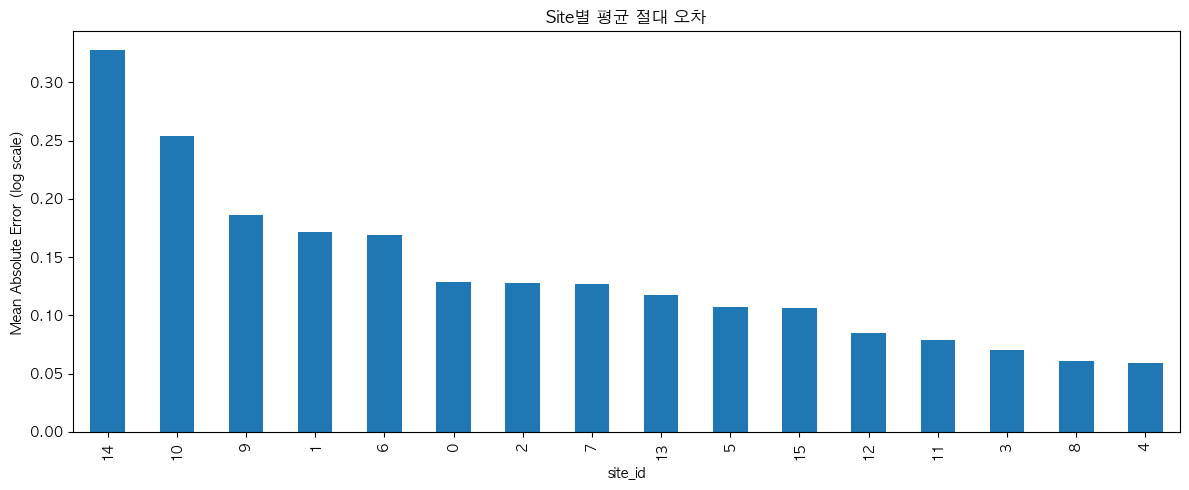

In [63]:
plt.figure(figsize=(12,5))
site_bias['mean_abs_error'].sort_values(ascending=False).plot(kind='bar')
plt.title('Site별 평균 절대 오차')
plt.ylabel('Mean Absolute Error (log scale)')
plt.tight_layout()
plt.show()

In [64]:
# 과대/과소 예측 편향 확인
# mean_error가 양수/음수로 치우친 site가 있는지
print(site_bias.sort_values('mean_error'))

         mean_error  mean_abs_error       n
site_id                                    
11        -0.005221        0.079045   20444
4         -0.004469        0.058643  132037
15        -0.003835        0.106465  335688
7         -0.003410        0.126918   61488
12        -0.002923        0.085158   52657
13        -0.002517        0.117262  450791
2         -0.002307        0.127356  421553
14        -0.002302        0.327476  418211
5         -0.001501        0.107243  130296
6         -0.000676        0.168846  113678
10         0.000259        0.253707   67106
8          0.000622        0.060821   87374
1          0.000900        0.171112   92231
3          0.003660        0.070015  394853
0          0.009258        0.128325  186996
9          0.013500        0.186480  447512


In [65]:
# 전체 건물 대비 오차 큰 건물의 비율이 유의미하게 높은지 확인
total_by_use = df   .groupby('primary_use')['building_id'].nunique()
worst_by_use = worst_info['primary_use'].value_counts()

ratio = (worst_by_use / total_by_use * 100).sort_values(ascending=False)
print(ratio)

primary_use
Technology/science               50.000000
Services                         10.000000
Office                            5.376344
Entertainment/public assembly     4.347826
Lodging/residential               3.401361
Education                         2.550091
Public services                   1.282051
Food sales and service                 NaN
Healthcare                             NaN
Manufacturing/industrial               NaN
Other                                  NaN
Parking                                NaN
Religious worship                      NaN
Retail                                 NaN
Utility                                NaN
Warehouse/storage                      NaN
dtype: float64


In [66]:
# site 14 안에서 어떤 meter/건물이 오차를 견인하는지 확인
site14_result = df_valid_result[df_valid_result['site_id']==14]
print(site14_result.groupby('meter')['abs_error'].mean().sort_values(ascending=False))

site14_building_error = site14_result.groupby('building_id')['abs_error'].mean().sort_values(ascending=False)
print(site14_building_error.head(10))

meter
3    0.654831
1    0.366533
2    0.341366
0    0.106604
Name: abs_error, dtype: float64
building_id
1302    1.107832
1253    1.089138
1256    0.892473
1270    0.874769
1251    0.707429
1223    0.700558
1258    0.656944
1305    0.608823
1246    0.593678
1260    0.557571
Name: abs_error, dtype: float64


In [67]:
# time split - validation strategy 확인
from sklearn.model_selection import train_test_split

# 만약 random split을 했다면 어떻게 됐을지 비교 실험
X_all = df[feature_cols]
y_all = df[target_col]

X_train_rand, X_valid_rand, y_train_rand, y_valid_rand = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42
)

train_data_rand = lgb.Dataset(X_train_rand, label=y_train_rand, categorical_feature=categorical_features)
valid_data_rand = lgb.Dataset(X_valid_rand, label=y_valid_rand, categorical_feature=categorical_features, reference=train_data_rand)

model_rand = lgb.train(
    params,
    train_data_rand,
    num_boost_round=1000,
    valid_sets=[train_data_rand, valid_data_rand],
    valid_names=['train', 'valid'],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

pred_rand = model_rand.predict(X_valid_rand, num_iteration=model_rand.best_iteration)
rmsle_rand = np.sqrt(mean_squared_error(y_valid_rand, pred_rand))

print(f'Time split RMSLE: 0.4121')
print(f'Random split RMSLE: {rmsle_rand:.4f}')

Training until validation scores don't improve for 50 rounds
[100]	train's rmse: 0.459364	valid's rmse: 0.462489
[200]	train's rmse: 0.429214	valid's rmse: 0.434082
[300]	train's rmse: 0.420569	valid's rmse: 0.42671
[400]	train's rmse: 0.415689	valid's rmse: 0.423064
[500]	train's rmse: 0.412261	valid's rmse: 0.420842
[600]	train's rmse: 0.409138	valid's rmse: 0.418907
[700]	train's rmse: 0.406526	valid's rmse: 0.417505
[800]	train's rmse: 0.404028	valid's rmse: 0.416236
[900]	train's rmse: 0.401766	valid's rmse: 0.415115
[1000]	train's rmse: 0.399406	valid's rmse: 0.413808
Did not meet early stopping. Best iteration is:
[1000]	train's rmse: 0.399406	valid's rmse: 0.413808
Time split RMSLE: 0.4121
Random split RMSLE: 0.4138


## 비즈니스 제안 분석

In [68]:
print(locals().keys())


dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__vsc_ipynb_file__', '_i', '_ii', '_iii', '_i1', 'time', 'LinearRegression', 'RandomForestRegressor', 'sample_frac', '_i2', 'lgb', 'mean_squared_error', 'np', 'categorical_features', '_i3', '_i4', 'pd', 'plt', 'sns', 'gc', '_i5', 'data_path', 'df', '_5', '_i6', 'feature_cols', 'target_col', 'missing_cols', '_i7', 'train_mask', 'valid_mask', 'X_train', 'y_train', 'X_valid', 'y_valid', 'split_date', 'train_idx', 'valid_idx', '_i8', 'train_sample_idx', 'X_train_sample', 'y_train_sample', 'ohe_cols', 'X_train_ohe', 'X_valid_ohe', '_i9', 'lr', 'start', 'lr_train_time', 'pred_lr', 'rmsle_lr', '_i10', 'rf', 'rf_train_time', 'pred_rf', 'rmsle_rf', '_i11', 'train_data_sample', 'valid_data_sample', '_i12', 'params', '_i13', 'model_sample', 'lgb_train_time', 'pred_lgb_sample', 'rmsle_lgb_sample', '_i14

RMSE: 1297.4500411318677

[시간대별 평균 오차]
hour
0     68.852120
1     68.908206
2     67.319876
3     65.574183
4     66.237983
5     74.938124
6     82.241471
7     85.694519
8     86.229596
9     82.750389
10    81.823864
11    79.857484
12    78.789049
13    77.995934
14    76.457966
15    78.113932
16    77.714436
17    78.560815
18    78.104659
19    75.467553
20    70.056656
21    69.958899
22    69.573479
23    71.574062
Name: error, dtype: float64

[피크 구간 평균 오차]
38836.68511395315


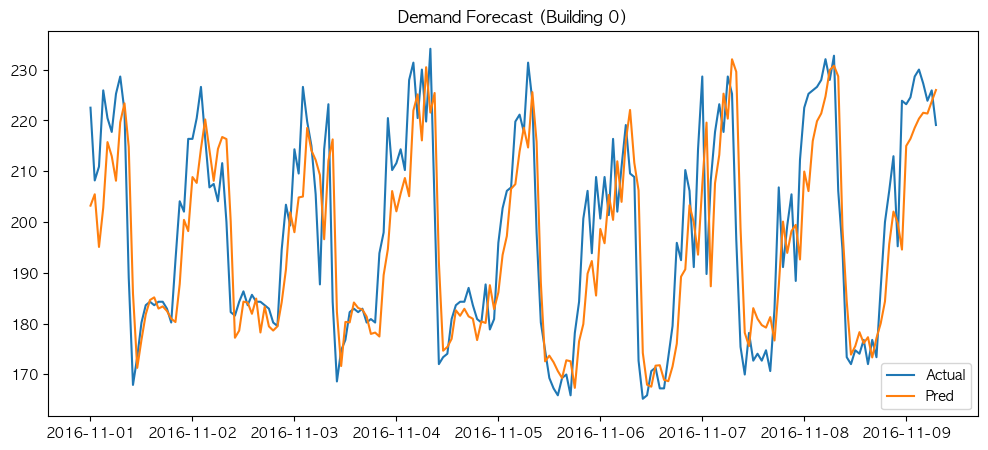

In [69]:
# =====================================
# 0. VALID 데이터 만들기 (핵심)
# =====================================
df_valid = df.loc[valid_idx].copy()
df_valid['timestamp'] = pd.to_datetime(df_valid['timestamp'])


# =====================================
# 1. 예측값 복원
# =====================================
df_valid['pred_log'] = model.predict(X_valid)
df_valid['pred'] = np.expm1(df_valid['pred_log'])
df_valid['actual'] = np.expm1(y_valid)


# =====================================
# 2. 기본 성능 확인
# =====================================
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(df_valid['actual'], df_valid['pred']))
print("RMSE:", rmse)


# =====================================
# 3. 수요 예측 분석
# =====================================

# 시간 정보 생성
df_valid['hour'] = df_valid['timestamp'].dt.hour
df_valid['dayofweek'] = df_valid['timestamp'].dt.dayofweek

# 오차 계산
df_valid['error'] = abs(df_valid['actual'] - df_valid['pred'])


# 3-1 시간대별 오차
hourly_error = df_valid.groupby('hour')['error'].mean()
print("\n[시간대별 평균 오차]")
print(hourly_error)


# 3-2 피크 구간 성능
top_usage = df_valid.nlargest(1000, 'actual')
peak_error = abs(top_usage['actual'] - top_usage['pred']).mean()

print("\n[피크 구간 평균 오차]")
print(peak_error)


# =====================================
# 4. 시계열 예측 시각화
# =====================================
import matplotlib.pyplot as plt

sample_building = df_valid['building_id'].iloc[0]

sample = df_valid[df_valid['building_id'] == sample_building]\
            .sort_values('timestamp').iloc[:200]

plt.figure(figsize=(12,5))
plt.plot(sample['timestamp'], sample['actual'], label='Actual')
plt.plot(sample['timestamp'], sample['pred'], label='Pred')
plt.legend()
plt.title(f"Demand Forecast (Building {sample_building})")
plt.show()



[이상치 비율]
0.010000249053961203

[Meter별 이상치 개수]
meter
0      747
1     3561
2    25141
3     4681
dtype: int64

[시간별 이상치 개수]
hour
0     1233
1     1289
2     1213
3     1193
4     1192
5     1314
6     1556
7     1692
8     1553
9     1608
10    1572
11    1635
12    1588
13    1527
14    1493
15    1500
16    1460
17    1507
18    1437
19    1396
20    1297
21    1263
22    1282
23    1330
dtype: int64

[이상 많은 건물 TOP10]
building_id
1258    1677
1148    1432
1197    1431
1168    1346
1159    1250
1284    1206
1088    1175
1104    1096
1107    1072
1021    1038
dtype: int64


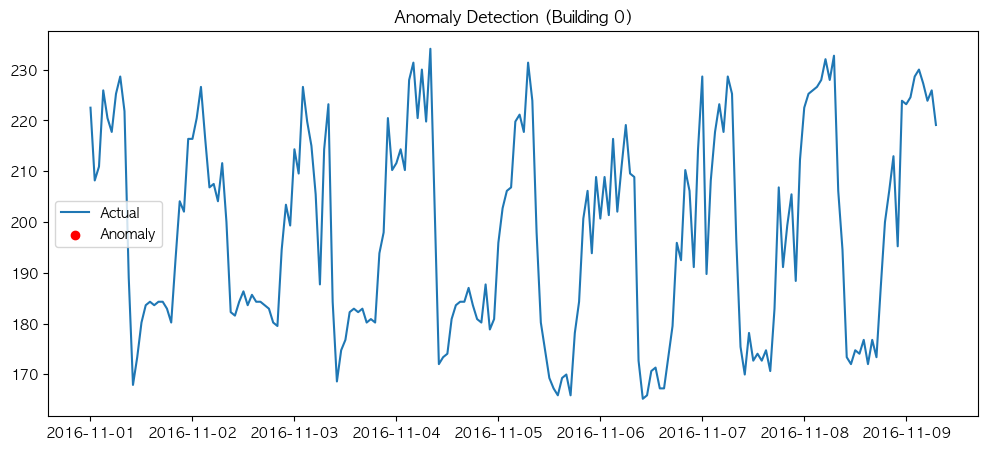

In [70]:
# =====================================
# 5. 이상 탐지 (Residual 기반)
# =====================================
df_valid['residual'] = df_valid['actual'] - df_valid['pred']
df_valid['abs_error'] = abs(df_valid['residual'])

threshold = df_valid['abs_error'].quantile(0.99)
df_valid['anomaly'] = df_valid['abs_error'] > threshold

print("\n[이상치 비율]")
print(df_valid['anomaly'].mean())


# =====================================
# 6. 이상 패턴 분석
# =====================================

# meter별
print("\n[Meter별 이상치 개수]")
print(df_valid[df_valid['anomaly']].groupby('meter').size())

# 시간별
print("\n[시간별 이상치 개수]")
print(df_valid[df_valid['anomaly']].groupby('hour').size())

# 건물별 TOP
print("\n[이상 많은 건물 TOP10]")
print(
    df_valid[df_valid['anomaly']]
    .groupby('building_id')
    .size()
    .sort_values(ascending=False)
    .head(10)
)


# =====================================
# 7. 이상 시각화
# =====================================
sample = df_valid[df_valid['building_id'] == sample_building]\
            .sort_values('timestamp').iloc[:200]

plt.figure(figsize=(12,5))
plt.plot(sample['timestamp'], sample['actual'], label='Actual')

anomaly_points = sample[sample['anomaly']]

plt.scatter(
    anomaly_points['timestamp'],
    anomaly_points['actual'],
    color='red',
    label='Anomaly'
)

plt.legend()
plt.title(f"Anomaly Detection (Building {sample_building})")
plt.show()


In [71]:
# =====================================
# 8. 고급 이상 탐지 (Rolling Z-score)
# =====================================
df_valid['rolling_mean'] = df_valid.groupby(['building_id','meter'])['actual']\
                                   .transform(lambda x: x.rolling(24).mean())

df_valid['rolling_std'] = df_valid.groupby(['building_id','meter'])['actual']\
                                  .transform(lambda x: x.rolling(24).std())

df_valid['z_score'] = (df_valid['actual'] - df_valid['rolling_mean']) / df_valid['rolling_std']

df_valid['anomaly_z'] = abs(df_valid['z_score']) > 3


# =====================================
# 9. 결과 통합
# =====================================
df_valid['use_case'] = np.where(df_valid['anomaly'], 'Anomaly', 'Normal')


# =====================================
# 10. 최종 요약
# =====================================
print("\n===== 최종 요약 =====")
print("RMSE:", rmse)
print("Anomaly Rate:", df_valid['anomaly'].mean())


===== 최종 요약 =====
RMSE: 1297.4500411318677
Anomaly Rate: 0.010000249053961203


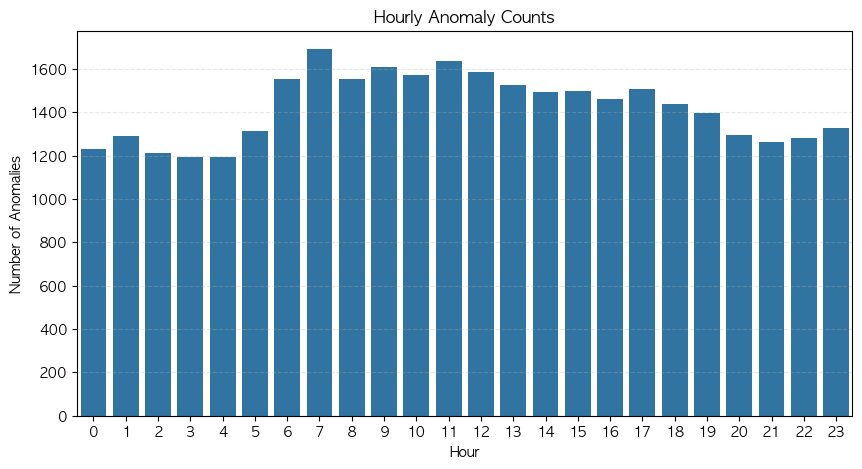

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

# 시간별 이상치 개수 계산 (네 코드 방식 유지)
hourly_anomaly = (
    df_valid[df_valid['anomaly']]
    .groupby('hour')
    .size()
    .reindex(range(24), fill_value=0)
)

plt.figure(figsize=(10,5))
sns.barplot(x=hourly_anomaly.index, y=hourly_anomaly.values)

plt.title("Hourly Anomaly Counts")
plt.xlabel("Hour")
plt.ylabel("Number of Anomalies")

plt.xticks(range(24))
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

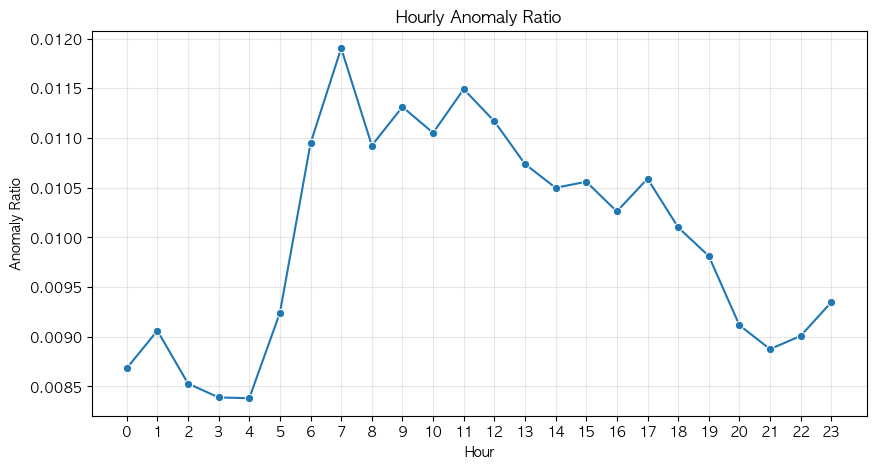

In [73]:
hourly_total = df_valid.groupby('hour').size()
hourly_ratio = hourly_anomaly / hourly_total

plt.figure(figsize=(10,5))
sns.lineplot(x=hourly_ratio.index, y=hourly_ratio.values, marker='o')

plt.title("Hourly Anomaly Ratio")
plt.xlabel("Hour")
plt.ylabel("Anomaly Ratio")

plt.xticks(range(24))
plt.grid(alpha=0.3)

plt.show()

## 이상 사례 하나 분석

In [74]:
anomaly_case = df_valid[df_valid['anomaly']].iloc[0]
print(anomaly_case)

building_id                        7
meter                              1
timestamp        2016-11-01 07:00:00
meter_reading                4009.98
site_id                            0
                        ...         
rolling_mean                     NaN
rolling_std                      NaN
z_score                          NaN
anomaly_z                      False
use_case                     Anomaly
Name: 76083, Length: 68, dtype: object


In [75]:
case_time = anomaly_case['timestamp']
case_building = anomaly_case['building_id']

window = df_valid[
    (df_valid['building_id'] == case_building) &
    (df_valid['timestamp'].between(case_time - pd.Timedelta(hours=3),
                                   case_time + pd.Timedelta(hours=3)))
]

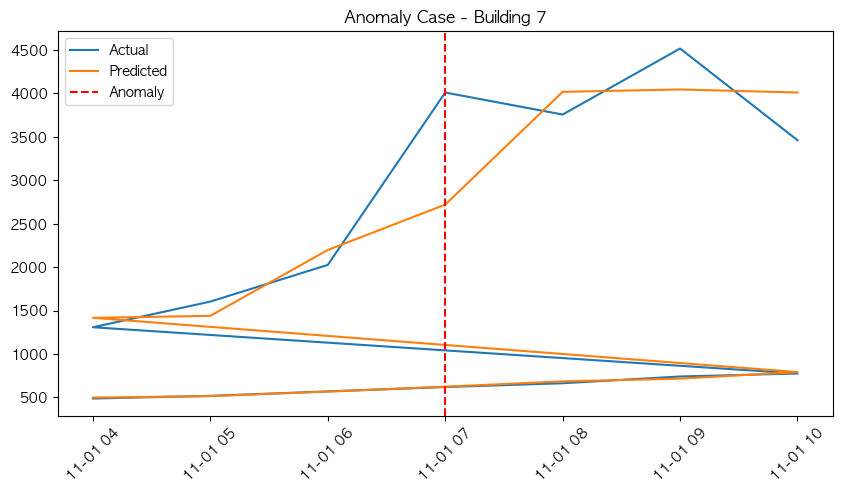

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(window['timestamp'], window['actual'], label='Actual')
plt.plot(window['timestamp'], window['pred'], label='Predicted')

plt.axvline(case_time, color='red', linestyle='--', label='Anomaly')

plt.legend()
plt.title(f"Anomaly Case - Building {case_building}")
plt.xticks(rotation=45)

plt.show()

In [77]:
print(anomaly_case[['meter', 'hour', 'building_id']])

meter          1
hour           7
building_id    7
Name: 76083, dtype: object


In [78]:
## 다른 건물 이상치
anomaly_case = df_valid[df_valid['anomaly']] \
    .sort_values('abs_error', ascending=False) \
    .iloc[0]

print(anomaly_case)


building_id                     1088
meter                              1
timestamp        2016-11-16 15:00:00
meter_reading               324098.0
site_id                           13
                        ...         
rolling_mean            13842.335734
rolling_std             66088.919655
z_score                     4.694522
anomaly_z                       True
use_case                     Anomaly
Name: 13512072, Length: 68, dtype: object


## 건물별 리스크 관리 분석

In [79]:
building_anomaly_count = (
    df_valid[df_valid['anomaly']]
    .groupby('building_id')
    .size()
    .sort_values(ascending=False)
)

print(building_anomaly_count.head(10))

building_id
1258    1677
1148    1432
1197    1431
1168    1346
1159    1250
1284    1206
1088    1175
1104    1096
1107    1072
1021    1038
dtype: int64


In [80]:
building_total = df_valid.groupby('building_id').size()
building_anomaly_ratio = building_anomaly_count / building_total

building_risk = (
    building_anomaly_ratio
    .sort_values(ascending=False)
)

print(building_risk.head(10))

building_id
1197    0.488730
1021    0.365236
1148    0.326047
1168    0.306466
783     0.300546
1258    0.286373
1159    0.284608
1284    0.274590
1088    0.267532
1072    0.255464
dtype: float64


In [81]:
high_risk_buildings = building_risk[building_risk > 0.02]  # 예: 2% 이상

print(high_risk_buildings)

building_id
1197    0.488730
1021    0.365236
1148    0.326047
1168    0.306466
783     0.300546
          ...   
1291    0.024131
1330    0.022338
1186    0.022199
954     0.021630
1117    0.020150
Length: 77, dtype: float64


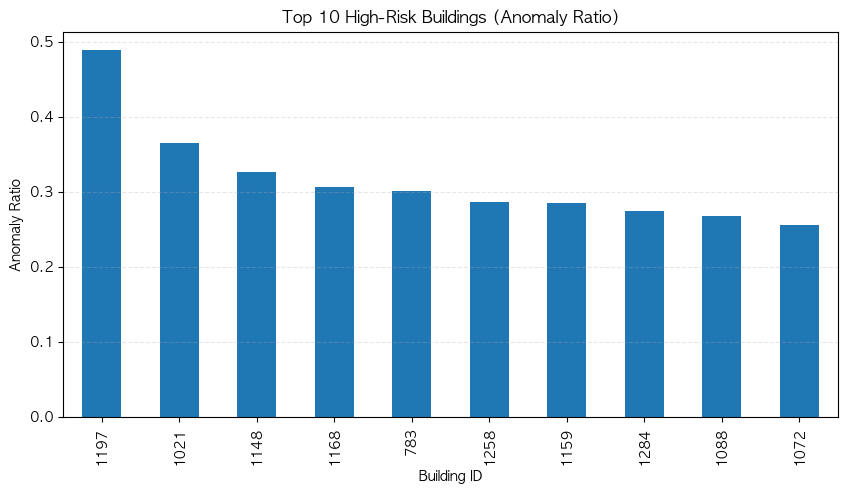

In [82]:
import matplotlib.pyplot as plt

top_risk = building_risk.head(10)

plt.figure(figsize=(10,5))
top_risk.plot(kind='bar')

plt.title("Top 10 High-Risk Buildings (Anomaly Ratio)")
plt.xlabel("Building ID")
plt.ylabel("Anomaly Ratio")

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

In [83]:
df_valid[df_valid['anomaly']].groupby(['building_id', 'meter']).size()

building_id  meter
7            1         75
9            1          8
13           1         78
14           1         44
15           1         90
                     ... 
1427         2          8
1433         2        179
1434         2          3
1436         2         12
1438         2          1
Length: 314, dtype: int64

In [84]:
top_buildings = (
    df_valid[df_valid['anomaly']]
    .groupby('building_id')
    .size()
    .sort_values(ascending=False)
    .head(10)
    .index
)

filtered = df_valid[
    (df_valid['anomaly']) &
    (df_valid['building_id'].isin(top_buildings))
]

plot_data = (
    filtered.groupby(['building_id', 'meter'])
    .size()
    .reset_index(name='count')
)

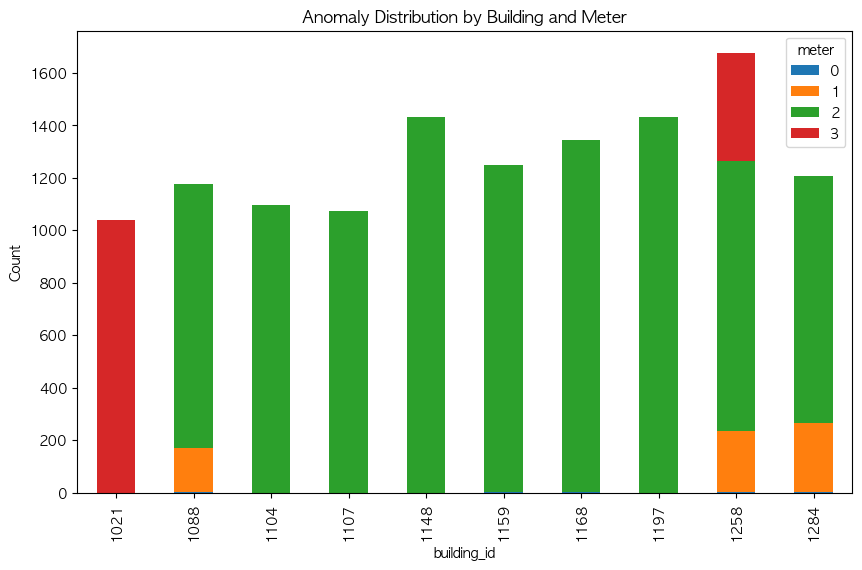

In [85]:
pivot_top = (
    filtered.groupby(['building_id', 'meter'])
    .size()
    .unstack(fill_value=0)
)

pivot_top.plot(kind='bar', stacked=True, figsize=(10,6))

plt.title("Anomaly Distribution by Building and Meter")
plt.ylabel("Count")
plt.show()

In [86]:
# 건물별 평균 오차까지 같이 보기
building_error = df_valid.groupby('building_id')['abs_error'].mean()

risk_table = pd.concat([building_anomaly_ratio, building_error], axis=1)
risk_table.columns = ['anomaly_ratio', 'avg_error']

print(risk_table.sort_values('anomaly_ratio', ascending=False).head(10))

             anomaly_ratio    avg_error
building_id                            
1197              0.488730  9541.102415
1021              0.365236  9630.896852
1148              0.326047  2910.326253
1168              0.306466  2146.530089
783               0.300546   448.590004
1258              0.286373   930.589260
1159              0.284608  1308.928504
1284              0.274590   783.136818
1088              0.267532  5777.145957
1072              0.255464   688.152545


## meter별 집중관리 

In [87]:
meter_anomaly = df_valid[df_valid['anomaly']].groupby('meter').size()
meter_total = df_valid.groupby('meter').size()

meter_ratio = (meter_anomaly / meter_total).sort_values(ascending=False)

print(meter_ratio)

meter
2    0.054383
3    0.022146
1    0.004973
0    0.000369
dtype: float64


In [88]:
meter_error = df_valid.groupby('meter')['abs_error'].mean()

meter_risk = pd.concat([meter_ratio, meter_error], axis=1)
meter_risk.columns = ['anomaly_ratio', 'avg_error']

print(meter_risk.sort_values('anomaly_ratio', ascending=False))

       anomaly_ratio   avg_error
meter                           
2           0.054383  312.632399
3           0.022146  221.290003
1           0.004973   67.464880
0           0.000369    8.984495


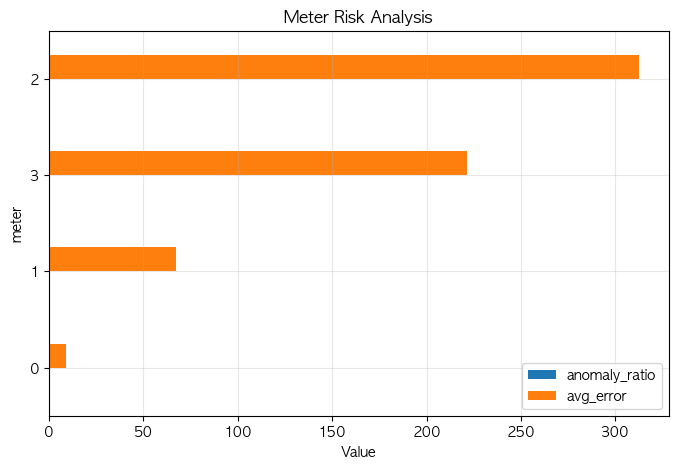

In [89]:
import matplotlib.pyplot as plt

meter_risk.sort_values('anomaly_ratio').plot(
    kind='barh', figsize=(8,5)
)

plt.title("Meter Risk Analysis")
plt.xlabel("Value")
plt.grid(alpha=0.3)
plt.show()

In [90]:
df_valid[df_valid['anomaly']].groupby(['meter', 'hour']).size().unstack()

hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
meter,,,,,,,,,,,,,,,,,,,,,,,,
0,8,12,13,20,14,45,121,46,43,28,24,28,29,29,39,47,43,49,52,25,12,9,6,5
1,123,105,109,89,84,90,144,243,124,145,176,234,181,155,155,178,166,173,198,162,121,111,137,158
2,950,991,941,922,909,976,1110,1197,1159,1201,1141,1153,1111,1110,1080,1047,1055,1106,1010,1041,990,977,976,988
3,152,181,150,162,185,203,181,206,227,234,231,220,267,233,219,228,196,179,177,168,174,166,163,179


In [91]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

meter_risk_scaled = pd.DataFrame(
    scaler.fit_transform(meter_risk),
    columns=meter_risk.columns,
    index=meter_risk.index
)

print(meter_risk_scaled)

       anomaly_ratio  avg_error
meter                          
2           1.000000   1.000000
3           0.403166   0.699183
1           0.085239   0.192593
0           0.000000   0.000000


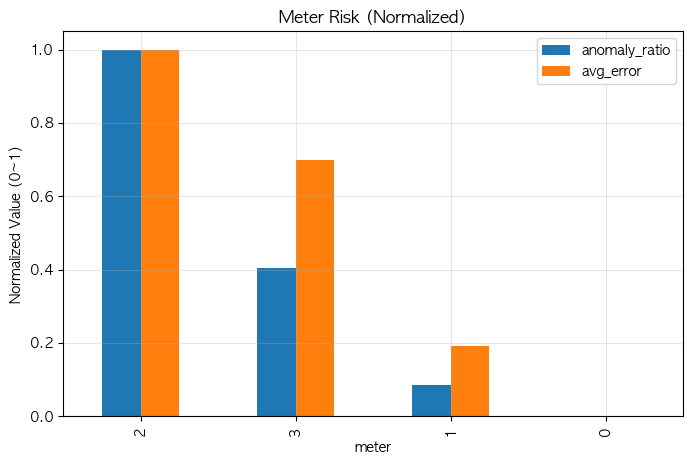

In [92]:
meter_risk_scaled.plot(kind='bar', figsize=(8,5))

plt.title("Meter Risk (Normalized)")
plt.ylabel("Normalized Value (0~1)")
plt.grid(alpha=0.3)
plt.show()

## 인사이트 

In [93]:
# 실제로 어떤 카테고리들이 있는지, 각각 건물이 몇 개나 있는지 확인
print(df['primary_use'].unique())
print()
print(df.groupby('primary_use')['building_id'].nunique().sort_values(ascending=False))

['Education' 'Lodging/residential' 'Office'
 'Entertainment/public assembly' 'Other' 'Retail' 'Parking'
 'Public services' 'Warehouse/storage' 'Food sales and service'
 'Religious worship' 'Healthcare' 'Utility' 'Technology/science'
 'Manufacturing/industrial' 'Services']

primary_use
Education                        549
Office                           279
Entertainment/public assembly    184
Public services                  156
Lodging/residential              147
Other                             25
Healthcare                        23
Parking                           22
Warehouse/storage                 13
Manufacturing/industrial          12
Retail                            11
Services                          10
Technology/science                 6
Food sales and service             5
Utility                            4
Religious worship                  3
Name: building_id, dtype: int64


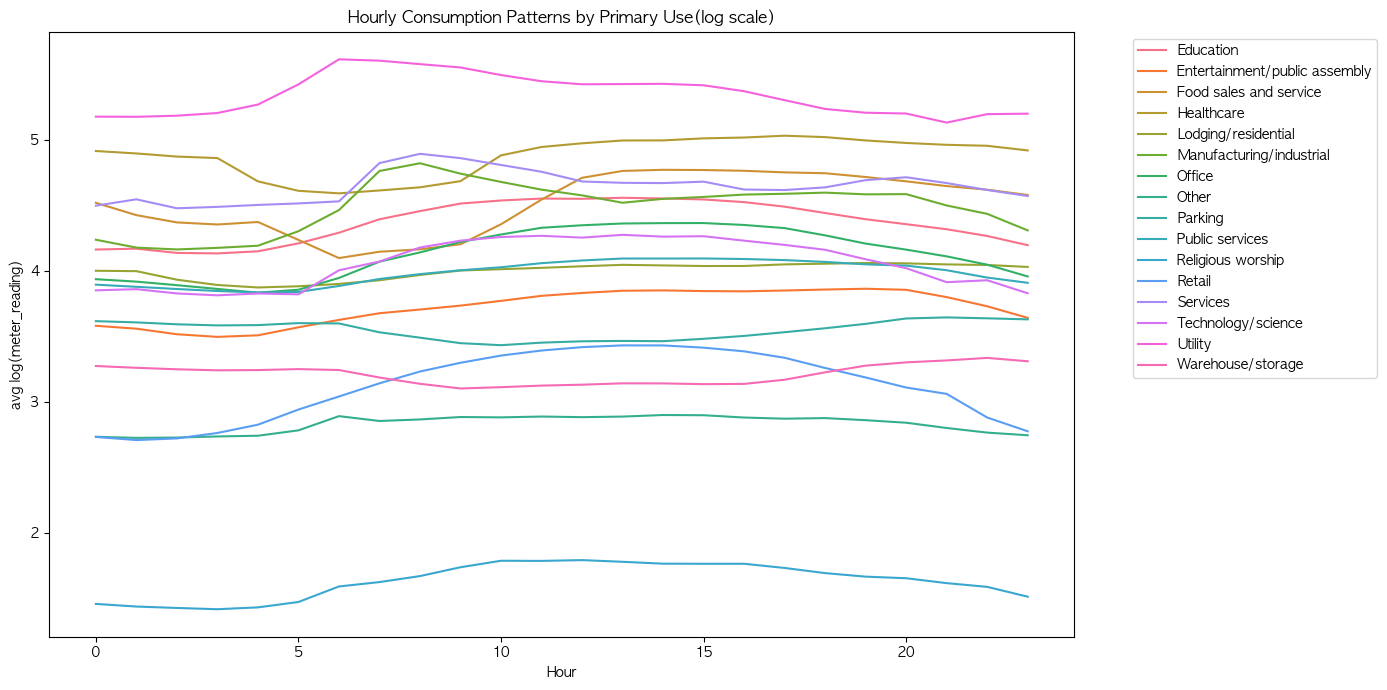

In [94]:
# log_meter_reading 기준으로 평균 (원본은 스케일 편차 크니까)
hourly_by_use = df.groupby(['primary_use', 'hour'])['log_meter_reading'].mean().reset_index()

plt.figure(figsize=(14,7))
sns.lineplot(data=hourly_by_use, x='hour', y='log_meter_reading', hue='primary_use')
plt.title('Hourly Consumption Patterns by Primary Use(log scale)')
plt.xlabel('Hour')
plt.ylabel('avg log(meter_reading)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

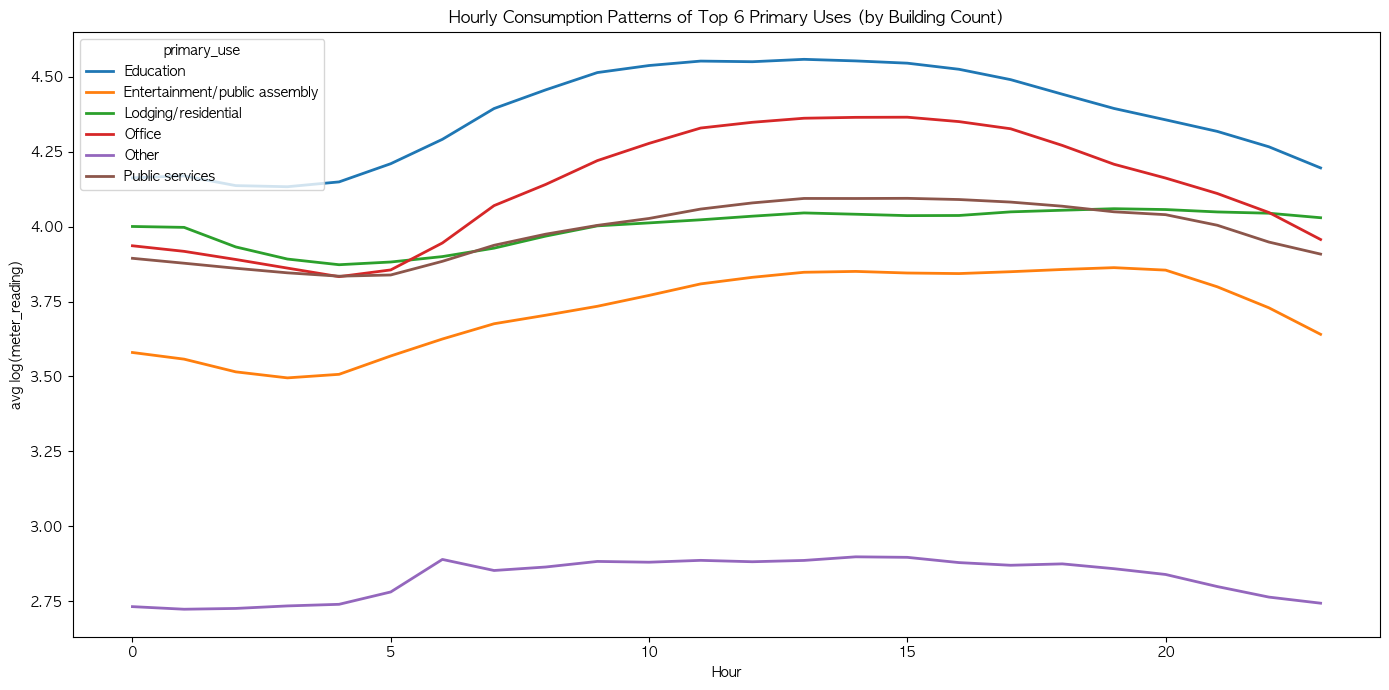

In [95]:
# 건물 수 상위 6개 primary_use의 시간대 소비 패턴
top_uses = df.groupby('primary_use')['building_id'].nunique().sort_values(ascending=False).head(6).index

hourly_top = df[df['primary_use'].isin(top_uses)].groupby(['primary_use', 'hour'])['log_meter_reading'].mean().reset_index()

plt.figure(figsize=(14,7))
sns.lineplot(data=hourly_top, x='hour', y='log_meter_reading', hue='primary_use', linewidth=2)
plt.title('Hourly Consumption Patterns of Top 6 Primary Uses (by Building Count)')
plt.xlabel('Hour')
plt.ylabel('avg log(meter_reading)')
plt.tight_layout()
plt.show()

In [96]:
# 피크 시각을 정량적으로 뽑기
peak_hour_by_use = hourly_by_use.loc[hourly_by_use.groupby('primary_use')['log_meter_reading'].idxmax()]
peak_hour_by_use = peak_hour_by_use[['primary_use', 'hour', 'log_meter_reading']].sort_values('primary_use')
print(peak_hour_by_use)

                       primary_use  hour  log_meter_reading
13                       Education    13           4.557845
43   Entertainment/public assembly    19           3.863002
62          Food sales and service    14           4.771425
89                      Healthcare    17           5.032065
115            Lodging/residential    19           4.059616
128       Manufacturing/industrial     8           4.821552
159                         Office    15           4.364808
182                          Other    14           2.898446
213                        Parking    21           3.644063
231                Public services    15           4.094203
252              Religious worship    12           1.789997
277                         Retail    13           3.430295
296                       Services     8           4.893595
325             Technology/science    13           4.274725
342                        Utility     6           5.615459
382              Warehouse/storage    22

In [97]:
weekday_use = df.groupby(['primary_use', 'is_weekend'])['log_meter_reading'].mean().unstack()
weekday_use.columns = ['평일', '주말']
weekday_use['평일대비_주말_비율'] = weekday_use['주말'] / weekday_use['평일']
print(weekday_use.sort_values('평일대비_주말_비율'))

                                     평일        주말  평일대비_주말_비율
primary_use                                                  
Retail                         3.199475  2.912309    0.910246
Office                         4.193741  3.974905    0.947818
Services                       4.707035  4.500663    0.956157
Education                      4.425359  4.234459    0.956862
Manufacturing/industrial       4.537758  4.366020    0.962153
Technology/science             4.101875  3.953980    0.963945
Warehouse/storage              3.239419  3.133473    0.967295
Utility                        5.392161  5.227011    0.969372
Religious worship              1.643336  1.595749    0.971042
Entertainment/public assembly  3.748871  3.658528    0.975901
Other                          2.848335  2.779789    0.975935
Public services                4.007458  3.921409    0.978528
Parking                        3.567991  3.495660    0.979728
Food sales and service         4.538625  4.448776    0.980203
Healthca

In [98]:
# 업무형 vs 상시형 그룹을 새 feature로 만들어서 
# 실제로 이게 예측에 도움되는지 확인해볼 수도 있음
weekday_dependent = ['Retail', 'Office', 'Services', 'Education', 'Manufacturing/industrial']
df['is_weekday_dependent'] = df['primary_use'].isin(weekday_dependent).astype(int)

# 이 새 feature와 log_meter_reading의 관계 간단히 확인
print(df.groupby(['is_weekday_dependent', 'is_weekend'])['log_meter_reading'].mean())

is_weekday_dependent  is_weekend
0                     0             3.922704
                      1             3.850863
1                     0             4.338842
                      1             4.137698
Name: log_meter_reading, dtype: float64


In [99]:
# site 13이 이상치 제거 후에도 여전히 높은지 확인 (중요!)
site_consumption = df.groupby('site_id')['meter_reading'].sum().sort_values(ascending=False)
print(site_consumption.head())

# site 13의 건물 수, 건물당 평균도 같이 봐야 "그냥 건물이 많아서"인지 구분됨
site_building_count = df.groupby('site_id')['building_id'].nunique()
print(site_building_count)

site_id
13    3.411846e+09
14    1.650979e+09
9     7.045676e+08
0     5.920142e+08
15    5.473845e+08
Name: meter_reading, dtype: float64
site_id
0     105
1      51
2     135
3     274
4      91
5      89
6      44
7      15
8      70
9     124
10     30
11      5
12     36
13    154
14    102
15    124
Name: building_id, dtype: int64


In [100]:
# 이상치 제거가 잘 적용된 df_clean으로 계산한 게 맞는지 확인
print(df[(df['building_id']==1099) & (df['meter']==2)].shape[0])  # 0이 나와야 정상

# site 13 안에서 건물별 소비 분포 확인 - 특정 건물 하나가 또 몰아주고 있는지
site13_building = df[df['site_id']==13].groupby('building_id')['meter_reading'].sum().sort_values(ascending=False)
print(site13_building.head(10))

0
building_id
1168    4.286342e+08
1197    3.904002e+08
1159    3.142415e+08
1148    2.638549e+08
1088    2.082382e+08
1156    1.284771e+08
1214    1.007068e+08
1104    9.432308e+07
1107    7.999353e+07
1154    7.610700e+07
Name: meter_reading, dtype: float64


In [101]:
import os
import json
 
SAVE_DIR = "artifacts"
os.makedirs(SAVE_DIR, exist_ok=True)
 
# 1. meter별 LightGBM 모델 저장 (재학습 없이 나중에 그대로 불러다 씀)
for meter_name, meter_model in models.items():
    meter_model.save_model(f"{SAVE_DIR}/model_{meter_name}.txt")
 
# 2. 최적화에 필요한 컬럼만 추려서 저장 (전체 df를 다 저장하면 용량이 크므로
#    building_id, meter, timestamp, hour + feature_cols만 남긴다)
#    parquet 대신 csv를 쓴 이유: pyarrow/fastparquet 설치 여부에 관계없이
#    pandas 기본 기능만으로 항상 동작하게 하기 위함(환경 의존성 최소화)
cols_to_save = list(set(["building_id", "meter", "timestamp", "hour"] + feature_cols))
df[cols_to_save].to_csv(f"{SAVE_DIR}/df_features.csv", index=False)
 
# 3. valid 구간을 나눈 기준(split_date)과 feature 목록도 같이 저장해야
#    독립 스크립트에서 동일한 기준으로 valid_idx를 재현할 수 있다
meta = {
    "split_date": "2016-11-01",
    "feature_cols": feature_cols,
    "target_col": target_col,
    "meter_names": {0: "electricity", 1: "chilledwater", 2: "steam", 3: "hotwater"},
}
with open(f"{SAVE_DIR}/meta.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)
 
print(f"저장 완료: {SAVE_DIR}/ 안에 model_*.txt, df_features.csv, meta.json")
 

저장 완료: artifacts/ 안에 model_*.txt, df_features.csv, meta.json
